# Train + Validation Center 10x10 SWIR EDA

This notebook analyzes only the combined `data/splits/train` and `data/splits/val` H5 files. The test split is intentionally not read. Each sample is reduced to the mean spectrum of the 10x10 patch centered in the 160x160 processed box.

In [17]:
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def find_project_root(start=Path.cwd().resolve()):
    for path in [start, *start.parents]:
        if (path / "data" / "splits" / "train").exists() and (path / "data" / "splits" / "val").exists():
            return path
    raise FileNotFoundError("Could not find data/splits/train and data/splits/val from this notebook location.")


def find_wavelength_mapping(root=ROOT):
    candidates = [
        root / "references" / "swir_hippa_wl_calib_rounded.npy",
        root / "references" / "swir_hippa_wl_calib.npy",
        root.parents[1] / "bruising" / "references" / "swir_hippa_wl_calib_rounded.npy",
        root.parents[1] / "bruising" / "references" / "swir_hippa_wl_calib.npy",
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError("Could not find SWIR wavelength mapping file.")


ROOT = find_project_root()
SPLIT_DIRS = [ROOT / "data" / "splits" / "train", ROOT / "data" / "splits" / "val"]
PATCH = 10
WAVELENGTHS_NM = np.load(find_wavelength_mapping(ROOT)).astype(float)
DISPLAY_WAVELENGTH_NM = 1292.0
DISPLAY_WAVELENGTH_INDEX = int(np.abs(WAVELENGTHS_NM - DISPLAY_WAVELENGTH_NM).argmin())

## Load train + validation center patches

The label rule matches the training code: `t0` is sound, datasets starting with `sound` are sound, and datasets starting with `bruised` are bruised.

In [18]:
def label_for(timepoint, dataset_name):
    name = dataset_name.lower()
    if timepoint == "t0" or name.startswith("sound"):
        return "sound"
    if name.startswith("bruised"):
        return "bruised"
    return None


def center_patch(cube, size=PATCH):
    h, w, _ = cube.shape
    r0 = h // 2 - size // 2
    c0 = w // 2 - size // 2
    return cube[r0:r0 + size, c0:c0 + size, :]


def collect_center_spectra(split_dirs=SPLIT_DIRS):
    rows, examples = [], {}
    for split_dir in split_dirs:
        for path in sorted(split_dir.glob("*.h5")):
            with h5py.File(path, "r") as f:
                for group_name, group in f.items():
                    timepoint = group_name.split("_")[-1]
                    for ds_name, ds in group.items():
                        y = label_for(timepoint, ds_name)
                        if y is None:
                            continue
                        cube = ds[...]
                        patch = center_patch(cube)
                        rows.append({
                            "split": split_dir.name,
                            "file": path.name,
                            "group": group_name,
                            "timepoint": timepoint,
                            "dataset": ds_name,
                            "label": y,
                            "spectrum": patch.mean(axis=(0, 1)),
                            "center_mean": float(patch.mean()),
                        })
                        examples.setdefault(y, (path.name, group_name, ds_name, cube))
    return pd.DataFrame(rows), examples

eda, examples = collect_center_spectra()
if eda.empty:
    searched = "".join(str(path) for path in SPLIT_DIRS)
    raise FileNotFoundError(f"No H5 samples found in train/val split folders: {searched}")
eda.drop(columns="spectrum").head()

,split,file,group,timepoint,dataset,label,center_mean
0,train,MICROTEC_28002_processed_boxes.h5,SWIR_t0,t0,bruised1,sound,109.887364
1,train,MICROTEC_28002_processed_boxes.h5,SWIR_t0,t0,bruised2,sound,116.701864
2,train,MICROTEC_28002_processed_boxes.h5,SWIR_t0,t0,bruised3,sound,113.518273
3,train,MICROTEC_28002_processed_boxes.h5,SWIR_t0,t0,bruised4,sound,113.975591
4,train,MICROTEC_28002_processed_boxes.h5,SWIR_t0,t0,sound1,sound,120.886500


## Sample counts

In [19]:
counts = pd.crosstab([eda["split"], eda["timepoint"]], eda["label"])
counts

label            bruised  sound
split timepoint                
train t0               0    752
      t1             376    376
      t3             376    376
val   t0               0     96
      t1              48     48
      t3              48     48

## Two example processed boxes with the central 10x10 analysis region

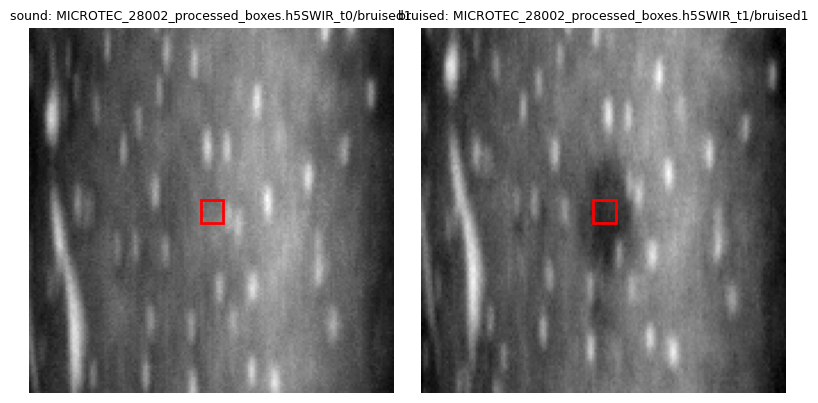

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, label in zip(axes, ["sound", "bruised"]):
    file, group, ds_name, cube = examples[label]
    h, w, _ = cube.shape
    r0 = h // 2 - PATCH // 2
    c0 = w // 2 - PATCH // 2
    ax.imshow(cube[:, :, min(DISPLAY_WAVELENGTH_INDEX, cube.shape[-1] - 1)], cmap="gray")
    ax.add_patch(Rectangle((c0, r0), PATCH, PATCH, fill=False, edgecolor="red", linewidth=2))
    ax.set_title(f"{label}: {file}{group}/{ds_name}", fontsize=9)
    ax.axis("off")
plt.tight_layout()

## Mean center-patch spectra by wavelength

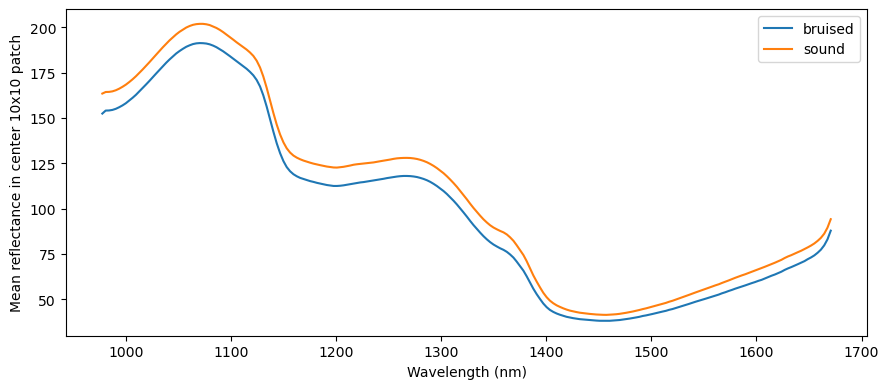

In [21]:
spectra = np.vstack(eda["spectrum"])
wavelengths_nm = WAVELENGTHS_NM[:spectra.shape[1]]
eda_spectra = pd.DataFrame(spectra, columns=wavelengths_nm).assign(label=eda["label"].to_numpy())
mean_spectra = eda_spectra.groupby("label")[wavelengths_nm].mean()

plt.figure(figsize=(9, 4))
for label, row in mean_spectra.iterrows():
    plt.plot(wavelengths_nm, row, label=label)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Mean reflectance in center 10x10 patch")
plt.legend()
plt.tight_layout()

## Most different wavelengths between bruised and sound center patches

In [22]:
diff = (mean_spectra.loc["bruised"] - mean_spectra.loc["sound"]).rename("bruised_minus_sound")
top_wavelengths = diff.abs().sort_values(ascending=False).head(15).index.to_numpy(dtype=float)
top_table = pd.DataFrame({
    "wavelength_nm": top_wavelengths,
    "sound_mean": mean_spectra.loc["sound", top_wavelengths].to_numpy(),
    "bruised_mean": mean_spectra.loc["bruised", top_wavelengths].to_numpy(),
    "bruised_minus_sound": diff.loc[top_wavelengths].to_numpy(),
})
top_table

,wavelength_nm,sound_mean,bruised_mean,bruised_minus_sound
0,977.4,163.421026,152.379552,-11.041474
1,1121.1,184.210277,173.488903,-10.721374
2,1117.9,186.099570,175.410908,-10.688662
3,1073.2,201.860407,191.197394,-10.663013
4,1089.2,198.547140,187.892276,-10.654864
5,1060.5,200.680312,190.034741,-10.645572
6,1124.3,181.550749,170.909163,-10.641586
7,1079.6,201.191279,190.568302,-10.622978
8,1076.4,201.626551,191.006781,-10.619770
9,1057.3,199.835578,189.218479,-10.617099


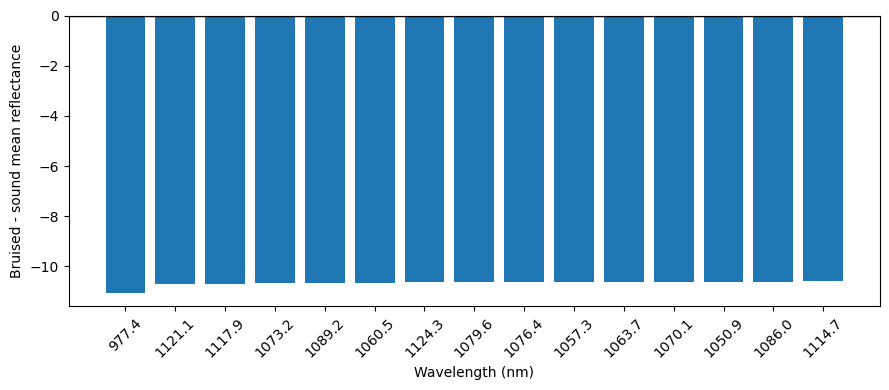

In [23]:
plt.figure(figsize=(9, 4))
plt.bar(top_table["wavelength_nm"].round(1).astype(str), top_table["bruised_minus_sound"])
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Bruised - sound mean reflectance")
plt.xticks(rotation=45)
plt.tight_layout()

## Center-patch mean intensity by label and timepoint

/tmp/ipykernel_2731572/1147259818.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=labels, showfliers=False)


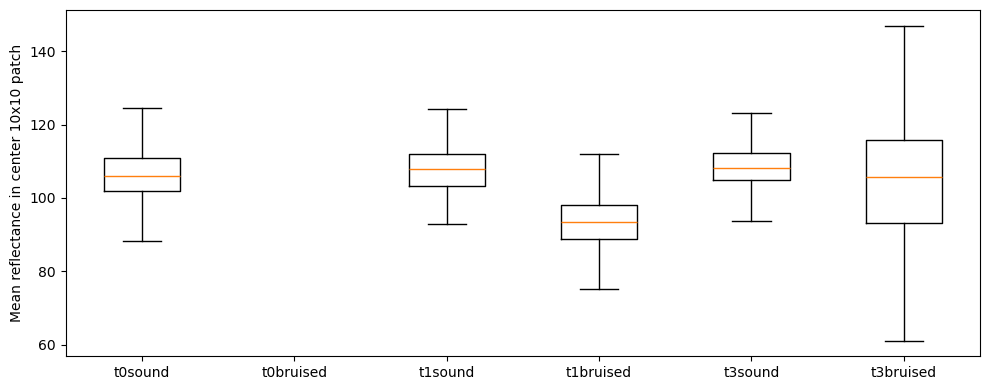

In [24]:
plot_data = [
    eda.loc[(eda["label"] == label) & (eda["timepoint"] == tp), "center_mean"].to_numpy()
    for tp in sorted(eda["timepoint"].unique())
    for label in ["sound", "bruised"]
]
labels = [f"{tp}{label}" for tp in sorted(eda["timepoint"].unique()) for label in ["sound", "bruised"]]

plt.figure(figsize=(10, 4))
plt.boxplot(plot_data, labels=labels, showfliers=False)
plt.ylabel("Mean reflectance in center 10x10 patch")
plt.tight_layout()

## Wavelength evolution across timepoints

These plots compare the center-patch mean spectra across timepoints for sound and bruised samples. The analysis still uses only train + validation data.

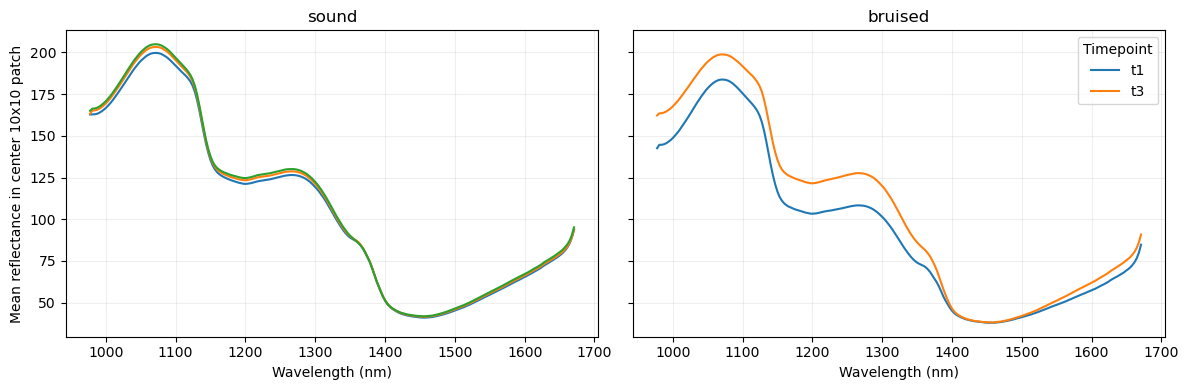

In [25]:
timepoint_mean = eda_spectra.assign(timepoint=eda["timepoint"].to_numpy()).groupby(["label", "timepoint"])[wavelengths_nm].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, label in zip(axes, ["sound", "bruised"]):
    for timepoint in sorted(eda["timepoint"].unique()):
        if (label, timepoint) in timepoint_mean.index:
            ax.plot(wavelengths_nm, timepoint_mean.loc[(label, timepoint)], label=timepoint)
    ax.set_title(label)
    ax.set_xlabel("Wavelength (nm)")
    ax.grid(alpha=0.2)
axes[0].set_ylabel("Mean reflectance in center 10x10 patch")
axes[1].legend(title="Timepoint")
plt.tight_layout()

## Change from t0 baseline

This shows how each label changes relative to its own `t0` spectrum. For bruised samples, `t0` is still treated as baseline/sound because that is the label rule used in the training data.

/tmp/ipykernel_2731572/251117362.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(title="Change")


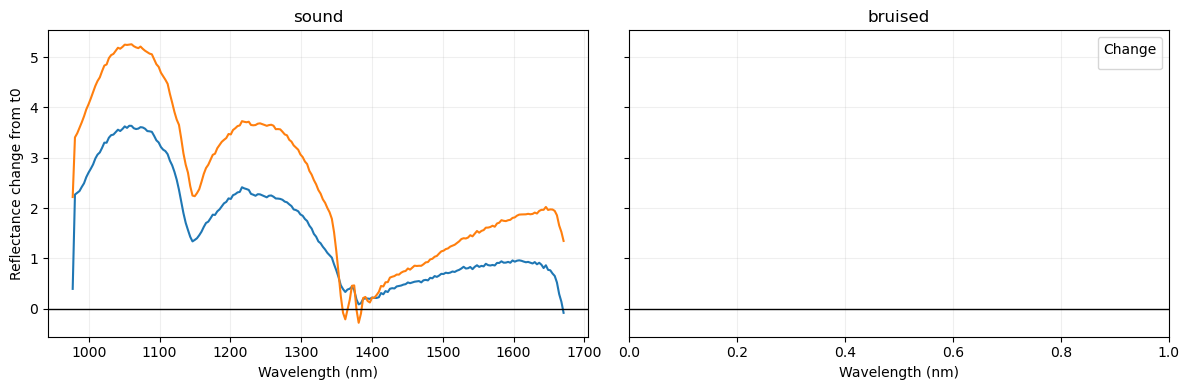

In [26]:
baseline_delta = {}
for label in ["sound", "bruised"]:
    available = [tp for tp in sorted(eda["timepoint"].unique()) if (label, tp) in timepoint_mean.index]
    if "t0" not in available:
        continue
    baseline = timepoint_mean.loc[(label, "t0")]
    baseline_delta[label] = {tp: timepoint_mean.loc[(label, tp)] - baseline for tp in available if tp != "t0"}

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, label in zip(axes, ["sound", "bruised"]):
    for timepoint, delta in baseline_delta.get(label, {}).items():
        ax.plot(wavelengths_nm, delta, label=f"{timepoint} - t0")
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(label)
    ax.set_xlabel("Wavelength (nm)")
    ax.grid(alpha=0.2)
axes[0].set_ylabel("Reflectance change from t0")
axes[1].legend(title="Change")
plt.tight_layout()

## Strongest evolving wavelengths

For each label and timepoint, this table records the wavelengths with the largest absolute change from `t0`.

In [27]:
evolution_rows = []
for label, deltas in baseline_delta.items():
    for timepoint, delta in deltas.items():
        for wavelength in delta.abs().sort_values(ascending=False).head(10).index:
            evolution_rows.append({
                "label": label,
                "timepoint": timepoint,
                "wavelength_nm": float(wavelength),
                "delta_from_t0": float(delta.loc[wavelength]),
                "abs_delta_from_t0": float(abs(delta.loc[wavelength])),
            })
evolution_table = pd.DataFrame(evolution_rows)
evolution_table.head(20)

,label,timepoint,wavelength_nm,delta_from_t0,abs_delta_from_t0
0,sound,t1,1057.3,3.634811,3.634811
1,sound,t1,1060.5,3.632830,3.632830
2,sound,t1,1050.9,3.622064,3.622064
3,sound,t1,1073.2,3.607300,3.607300
4,sound,t1,1076.4,3.600295,3.600295
5,sound,t1,1054.1,3.592406,3.592406
6,sound,t1,1063.7,3.585354,3.585354
7,sound,t1,1070.1,3.578278,3.578278
8,sound,t1,1079.6,3.575601,3.575601
9,sound,t1,1047.7,3.570672,3.570672


## Bruised minus sound dynamics

This tracks how the bruised-vs-sound separation changes by timepoint at each wavelength.

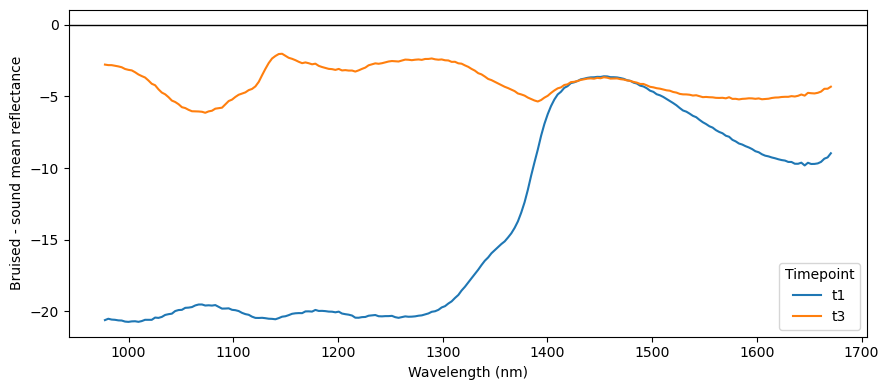

In [28]:
separation = {}
for timepoint in sorted(eda["timepoint"].unique()):
    if ("bruised", timepoint) in timepoint_mean.index and ("sound", timepoint) in timepoint_mean.index:
        separation[timepoint] = timepoint_mean.loc[("bruised", timepoint)] - timepoint_mean.loc[("sound", timepoint)]

plt.figure(figsize=(9, 4))
for timepoint, diff_curve in separation.items():
    plt.plot(wavelengths_nm, diff_curve, label=timepoint)
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Bruised - sound mean reflectance")
plt.legend(title="Timepoint")
plt.tight_layout()

In [29]:
separation_rows = []
for timepoint, diff_curve in separation.items():
    for wavelength in diff_curve.abs().sort_values(ascending=False).head(10).index:
        separation_rows.append({
            "timepoint": timepoint,
            "wavelength_nm": float(wavelength),
            "bruised_minus_sound": float(diff_curve.loc[wavelength]),
            "abs_bruised_minus_sound": float(abs(diff_curve.loc[wavelength])),
        })
separation_table = pd.DataFrame(separation_rows)
separation_table.head(20)

,timepoint,wavelength_nm,bruised_minus_sound,abs_bruised_minus_sound
0,t1,999.8,-20.736887,20.736887
1,t1,1009.4,-20.733868,20.733868
2,t1,996.6,-20.716085,20.716085
3,t1,1003.0,-20.702972,20.702972
4,t1,1006.2,-20.693514,20.693514
5,t1,1012.5,-20.682665,20.682665
6,t1,993.4,-20.643208,20.643208
7,t1,990.2,-20.632524,20.632524
8,t1,977.4,-20.613561,20.613561
9,t1,1022.1,-20.593939,20.593939


In [30]:
evolution_table.to_csv(out / "eda_train_val_center_10x10_wavelength_evolution_from_t0.csv", index=False)
separation_table.to_csv(out / "eda_train_val_center_10x10_bruised_sound_separation_by_timepoint.csv", index=False)

## Save compact EDA tables

In [31]:
out = ROOT / "reports" / "tables"
out.mkdir(parents=True, exist_ok=True)
counts.to_csv(out / "eda_train_val_center_10x10_counts.csv")
top_table.to_csv(out / "eda_train_val_center_10x10_top_wavelengths.csv", index=False)
eda.drop(columns="spectrum").to_csv(out / "eda_train_val_center_10x10_samples.csv", index=False)